<h2>Evaluación del desempeño de SVM en la clasificación de imágenes de perros y gatos - Aprendizaje Automático 2-2024</h2>

* <h5>Nombre: Xavier Muñoz Díaz</h3>
* <h5>Profesora: Violeta Chang Camacho</h3>
* <h5>Ayudante: Marcelo Guzmán</h3>

<h3>Breve Contexto</h3>

El objetivo de este laboratorio es evaluar el desempeño de un clasificador SVM para la clasificación de imágenes de perros y gatos. Para ello, se utilizará el conjunto de datos Cats & Dogs.

Para llevar a cabo este análisis, se realizarán dos experimentos en los que se variarán las estrategias de generación de vectores de características a partir de las imágenes:

1) Entrenar una SVM usando un kernel RBF y un kernel alternativo, transformando las imágenes de tamaño unificado directamente en vectores.

2) Similar al experimento anterior pero con la diferencia que se debe aplicar PCA para reducir los vectores a 256 dimensiones.

Los datos de entrenamiento incluirán 4000 imágenes de cada clase, y el conjunto de prueba incluirá 1000 imágenes de cada clase. Los resultados se analizarán en términos de precisión, tanto para cada categoría como a nivel global, y se presentarán mediante tablas y gráficos.

<h3>Importaciones de Librerias</h3>

In [26]:
import os
import cv2
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
import time

<h3>Carga de datasets de entrenamiento y prueba y etiquetado</h3>

In [27]:
#Descripción:
#Entrada:
#Salida:
def cargar_imagenes(ruta, tamanyo=(64, 64)):
    etiquetas = []
    imagenes = []
    for clase in ['cats', 'dogs']:
        ruta_clase = os.path.join(ruta, clase)
        etiqueta = 0 if clase == 'cats' else 1
        for archivo in os.listdir(ruta_clase):
            if not archivo.lower().endswith(('.jpg')):
                continue

            ruta_imagen = os.path.join(ruta_clase, archivo)
            imagen = cv2.imread(ruta_imagen, cv2.IMREAD_GRAYSCALE)
            
            if imagen is None:
                print(f"No se pudo cargar la imagen: {ruta_imagen}")
                continue
            
            imagen = cv2.resize(imagen, tamanyo)
            imagenes.append(imagen.flatten())
            etiquetas.append(etiqueta)
            
    return np.array(imagenes), np.array(etiquetas)

ruta_entrenamiento = 'training_set'
ruta_prueba = 'valid_set'
imagenes_entrenamiento, etiquetas_entrenamiento = cargar_imagenes(ruta_entrenamiento)
imagenes_prueba, etiquetas_prueba = cargar_imagenes(ruta_prueba)

In [28]:
'''
# Seleccionar 30 índices aleatorios<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<BORRARRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRR<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
indices_aleatorios = np.random.choice(len(imagenes_entrenamiento), size=30, replace=False)

# Obtener las imágenes y etiquetas correspondientes
imagenes_aleatorias = [imagenes_entrenamiento[i].reshape(64, 64) for i in indices_aleatorios]
etiquetas_aleatorias = [etiquetas_entrenamiento[i] for i in indices_aleatorios]

# Mostrar las 30 imágenes con sus etiquetas
fig, axes = plt.subplots(3, 10, figsize=(20, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(imagenes_aleatorias[i], cmap='gray')
    ax.axis('off')
    ax.set_title(f'Etiqueta: {"Gato" if etiquetas_aleatorias[i] == 0 else "Perro"}')
plt.show()
'''

'\n# Seleccionar 30 índices aleatorios<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<BORRARRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRR<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<\nindices_aleatorios = np.random.choice(len(imagenes_entrenamiento), size=30, replace=False)\n\n# Obtener las imágenes y etiquetas correspondientes\nimagenes_aleatorias = [imagenes_entrenamiento[i].reshape(64, 64) for i in indices_aleatorios]\netiquetas_aleatorias = [etiquetas_entrenamiento[i] for i in indices_aleatorios]\n\n# Mostrar las 30 imágenes con sus etiquetas\nfig, axes = plt.subplots(3, 10, figsize=(20, 6))\nfor i, ax in enumerate(axes.flat):\n    ax.imshow(imagenes_aleatorias[i], cmap=\'gray\')\n    ax.axis(\'off\')\n    ax.set_title(f\'Etiqueta: {"Gato" if etiquetas_aleatorias[i] == 0 else "Perro"}\')\nplt.show()\n'

<h2>Experimento 1</h2>

In [29]:
def evaluar_modelo(pipeline, datos_entrenamiento, datos_prueba, etiquetas_entrenamiento, etiquetas_prueba, nombre_kernel="SVM"):
    pipeline.fit(datos_entrenamiento, etiquetas_entrenamiento)
    predicciones = pipeline.predict(datos_prueba)
    precision = accuracy_score(etiquetas_prueba, predicciones)

    print(f"Precisión en conjunto de prueba con kernel {nombre_kernel}: {precision}")
    print(f"Reporte de Clasificación para kernel {nombre_kernel}:")
    print(classification_report(etiquetas_prueba, predicciones, target_names=['Gatos', 'Perros']))
    
    matriz_confusion = confusion_matrix(etiquetas_prueba, predicciones)
    
    return precision, predicciones, matriz_confusion


In [30]:
pipeline_svm_rbf = Pipeline([
    ('escalador', StandardScaler()), 
    ('svm_rbf', SVC(kernel='rbf', gamma=0.000625)) 
])


pipeline_svm_linear = Pipeline([
    ('escalador', StandardScaler()),  
    ('svm_linear', SVC(kernel='sigmoid'))
])


accuracy_rbf, predicciones_rbf, matriz_confusion_rbf = evaluar_modelo(
    pipeline_svm_rbf, imagenes_entrenamiento, imagenes_prueba, etiquetas_entrenamiento, etiquetas_prueba, nombre_kernel="RBF"
    )

accuracy_linear, predicciones_linear, matriz_confusion_linear = evaluar_modelo(
    pipeline_svm_linear, imagenes_entrenamiento, imagenes_prueba, etiquetas_entrenamiento, etiquetas_prueba, nombre_kernel="Sigmoid"
    )


Precisión en conjunto de prueba con kernel RBF: 0.6500247157686604
Reporte de Clasificación para kernel RBF:
              precision    recall  f1-score   support

       Gatos       0.65      0.65      0.65      1011
      Perros       0.65      0.65      0.65      1012

    accuracy                           0.65      2023
   macro avg       0.65      0.65      0.65      2023
weighted avg       0.65      0.65      0.65      2023

Precisión en conjunto de prueba con kernel Sigmoid: 0.5012357884330203
Reporte de Clasificación para kernel Sigmoid:
              precision    recall  f1-score   support

       Gatos       0.50      0.51      0.51      1011
      Perros       0.50      0.49      0.50      1012

    accuracy                           0.50      2023
   macro avg       0.50      0.50      0.50      2023
weighted avg       0.50      0.50      0.50      2023



<h3>Gráficos ................</h3>


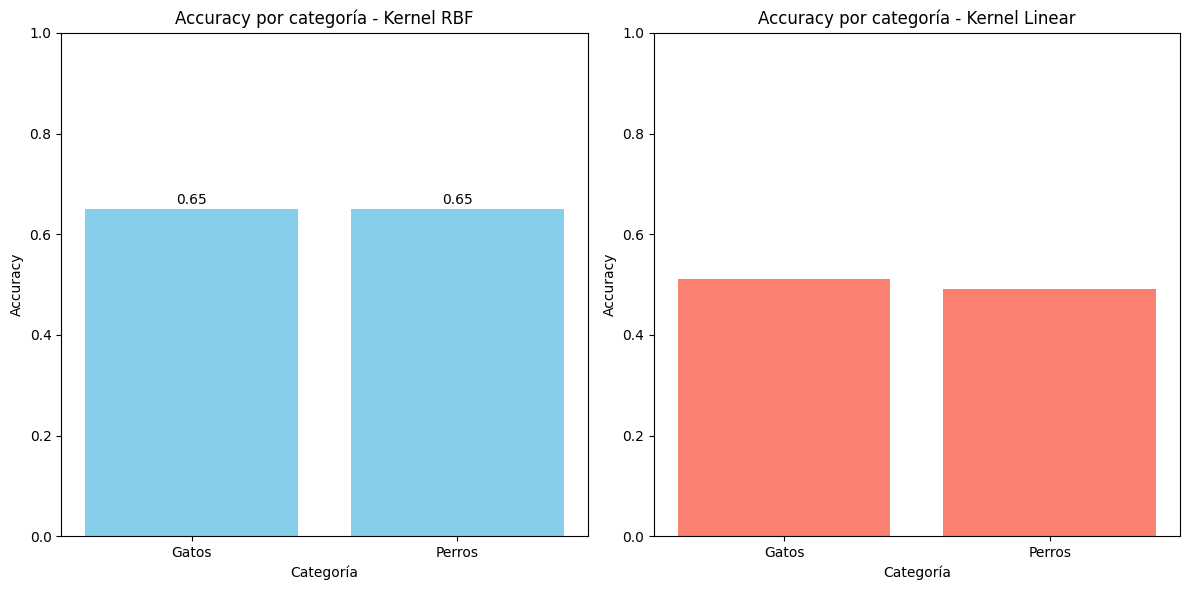

Accuracy total con kernel RBF: 0.6500247157686604


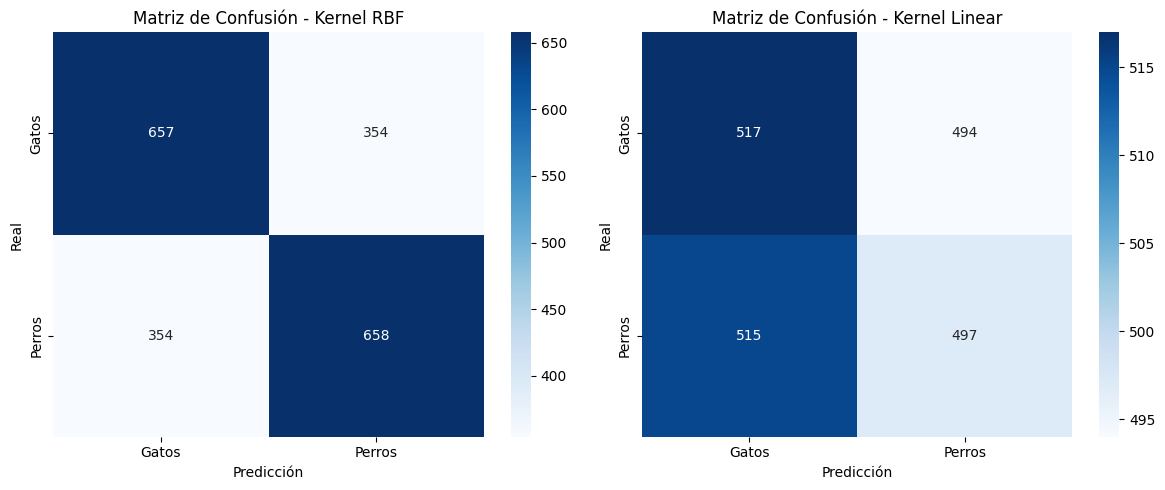

In [31]:
# Gráficos de barras para el accuracy de cada categoría
categorias = ['Gatos', 'Perros']
accuracies_rbf = np.diag(matriz_confusion_rbf) / np.sum(matriz_confusion_rbf, axis=1)
accuracies_linear = np.diag(matriz_confusion_linear) / np.sum(matriz_confusion_linear, axis=1)

plt.figure(figsize=(12, 6))
x = np.arange(len(categorias))

# Gráfico de barras para el modelo RBF
plt.subplot(1, 2, 1)
barras_rbf = plt.bar(x, accuracies_rbf, color='skyblue')
plt.xticks(x, categorias)
plt.ylim(0, 1)
plt.title('Accuracy por categoría - Kernel RBF')
plt.xlabel('Categoría')
plt.ylabel('Accuracy')
for barra in barras_rbf:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width() / 2, yval + 0.01, f"{yval:.2f}", ha="center")


# Gráfico de barras para el modelo Linear
plt.subplot(1, 2, 2)
plt.bar(x, accuracies_linear, color='salmon')
plt.xticks(x, categorias)
plt.ylim(0, 1)
plt.title('Accuracy por categoría - Kernel Linear')
plt.xlabel('Categoría')
plt.ylabel('Accuracy')

plt.tight_layout()
plt.show()

# Imprimir el accuracy total de cada modelo
print("Accuracy total con kernel RBF:", accuracy_rbf)
#print("Accuracy total con kernel Linear:", accuracy_linear)

# Mostrar la matriz de confusión para cada modelo
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(matriz_confusion_rbf, annot=True, fmt='d', cmap='Blues', xticklabels=categorias, yticklabels=categorias)
plt.title("Matriz de Confusión - Kernel RBF")
plt.xlabel("Predicción")
plt.ylabel("Real")


plt.subplot(1, 2, 2)
sns.heatmap(matriz_confusion_linear, annot=True, fmt='d', cmap='Blues', xticklabels=categorias, yticklabels=categorias)
plt.title("Matriz de Confusión - Kernel Linear")
plt.xlabel("Predicción")
plt.ylabel("Real")


plt.tight_layout()
plt.show()

<h2>Experimento 2</h2>

In [32]:
def evaluar_modelo_con_pca(pipeline, datos_entrenamiento, datos_prueba, etiquetas_entrenamiento, etiquetas_prueba, nombre_kernel="SVM"):
    pipeline.fit(datos_entrenamiento, etiquetas_entrenamiento)
    predicciones = pipeline.predict(datos_prueba)
    precision = accuracy_score(etiquetas_prueba, predicciones)
    
    print(f"Precisión en conjunto de prueba con kernel {nombre_kernel}: {precision}")
    print(f"Reporte de Clasificación para kernel {nombre_kernel}:")
    print(classification_report(etiquetas_prueba, predicciones, target_names=['Gatos', 'Perros']))
    
    matriz_confusion = confusion_matrix(etiquetas_prueba, predicciones)
    print(f"Matriz de Confusión para kernel {nombre_kernel}:\n{matriz_confusion}")
    
    return precision, predicciones, matriz_confusion


In [33]:
# Configuración de pipelines con PCA para SVM con RBF y Sigmoid
pipeline_svm_rbf = Pipeline([
    ('escalador', StandardScaler()), 
    ('pca', PCA(n_components=256)),   
    ('svm_rbf', SVC(kernel='rbf', C=1, gamma=0.000625))  # Valores optimizados
])

pipeline_svm_sigmoid = Pipeline([
    ('escalador', StandardScaler()), 
    ('pca', PCA(n_components=256)),   
    ('svm_sigmoid', SVC(kernel='sigmoid', C=0.4, gamma=6.5e-05))  # Valores optimizados
])

# Evaluar ambos modelos y almacenar los resultados
resultados_rbf = evaluar_modelo(
    pipeline_svm_rbf, imagenes_entrenamiento, imagenes_prueba, etiquetas_entrenamiento, etiquetas_prueba, nombre_kernel="RBF"
)

resultados_sigmoid = evaluar_modelo(
    pipeline_svm_sigmoid, imagenes_entrenamiento, imagenes_prueba, etiquetas_entrenamiento, etiquetas_prueba, nombre_kernel="Sigmoid"
)

Precisión en conjunto de prueba con kernel RBF: 0.6495304003954523
Reporte de Clasificación para kernel RBF:
              precision    recall  f1-score   support

       Gatos       0.64      0.68      0.66      1011
      Perros       0.66      0.62      0.64      1012

    accuracy                           0.65      2023
   macro avg       0.65      0.65      0.65      2023
weighted avg       0.65      0.65      0.65      2023

Precisión en conjunto de prueba con kernel Sigmoid: 0.5699456253089471
Reporte de Clasificación para kernel Sigmoid:
              precision    recall  f1-score   support

       Gatos       0.58      0.52      0.55      1011
      Perros       0.56      0.62      0.59      1012

    accuracy                           0.57      2023
   macro avg       0.57      0.57      0.57      2023
weighted avg       0.57      0.57      0.57      2023



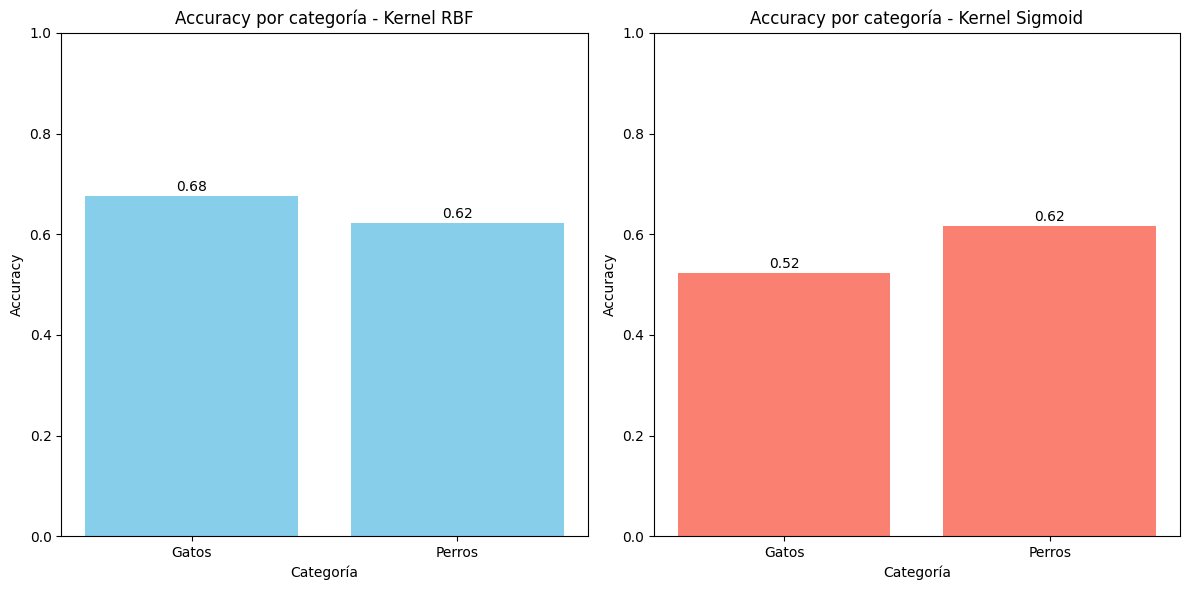

Accuracy total con kernel RBF: 0.6495304003954523
Accuracy total con kernel Sigmoid: 0.5699456253089471


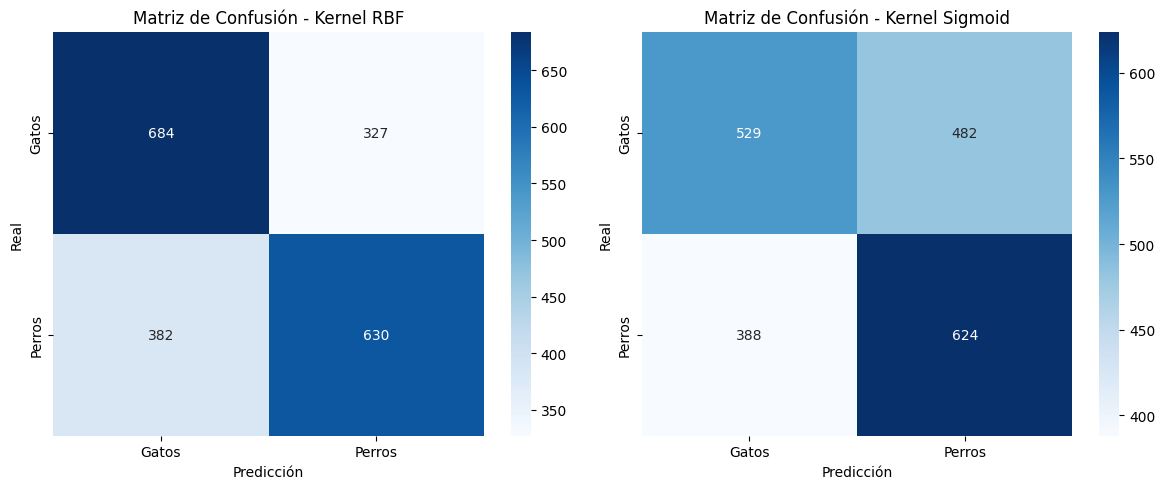

In [34]:
# Graficar los resultados
categorias = ['Gatos', 'Perros']
accuracies_rbf = np.diag(resultados_rbf[2]) / np.sum(resultados_rbf[2], axis=1)
accuracies_sigmoid = np.diag(resultados_sigmoid[2]) / np.sum(resultados_sigmoid[2], axis=1)

plt.figure(figsize=(12, 6))
x = np.arange(len(categorias))

# Gráfico de barras para el modelo RBF
plt.subplot(1, 2, 1)
barras_rbf = plt.bar(x, accuracies_rbf, color='skyblue')
plt.xticks(x, categorias)
plt.ylim(0, 1)
plt.title('Accuracy por categoría - Kernel RBF')
plt.xlabel('Categoría')
plt.ylabel('Accuracy')
for barra in barras_rbf:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width() / 2, yval + 0.01, f"{yval:.2f}", ha="center")

# Gráfico de barras para el modelo Sigmoid
plt.subplot(1, 2, 2)
barras_sigmoid = plt.bar(x, accuracies_sigmoid, color='salmon')
plt.xticks(x, categorias)
plt.ylim(0, 1)
plt.title('Accuracy por categoría - Kernel Sigmoid')
plt.xlabel('Categoría')
plt.ylabel('Accuracy')
for barra in barras_sigmoid:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width() / 2, yval + 0.01, f"{yval:.2f}", ha="center")

plt.tight_layout()
plt.show()

# Imprimir el accuracy total de cada modelo
print("Accuracy total con kernel RBF:", resultados_rbf[0])
print("Accuracy total con kernel Sigmoid:", resultados_sigmoid[0])

# Mostrar la matriz de confusión para cada modelo
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(resultados_rbf[2], annot=True, fmt='d', cmap='Blues', xticklabels=categorias, yticklabels=categorias)
plt.title("Matriz de Confusión - Kernel RBF")
plt.xlabel("Predicción")
plt.ylabel("Real")

plt.subplot(1, 2, 2)
sns.heatmap(resultados_sigmoid[2], annot=True, fmt='d', cmap='Blues', xticklabels=categorias, yticklabels=categorias)
plt.title("Matriz de Confusión - Kernel Sigmoid")
plt.xlabel("Predicción")
plt.ylabel("Real")

plt.tight_layout()
plt.show()